<a href="https://colab.research.google.com/github/IbrahimBajwa313/DataSciencePrjects/blob/master/Logisctic%20Regression%20on%20titanic%20DataSet%20By%20Ibrahim%20Bajwa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




## Logistic Regression on titanic Data Set by Ibrahim Bajwa




In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
)

In [7]:
# 2. Load the Titanic dataset
data = sns.load_dataset('titanic')

# Show first few rows
print("----- Dataset Preview -----")
print(data.head())


----- Dataset Preview -----
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [8]:
# 3. Select useful features
data = data[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]



In [9]:
# 4. Handle missing values
data['age'].fillna(data['age'].median(), inplace=True)
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)

# 5. Encode categorical variables
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data = pd.get_dummies(data, columns=['embarked'], drop_first=True)


/tmp/ipython-input-2429899474.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].median(), inplace=True)
/tmp/ipython-input-2429899474.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [10]:
X = data.drop('survived', axis=1)
y = data['survived']

In [11]:
#   Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
#  Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
  # Train logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

#  Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [15]:
# 🔹 Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.8044692737430168
ROC AUC Score: 0.8433465085638999

Confusion Matrix:
 [[98 12]
 [23 46]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



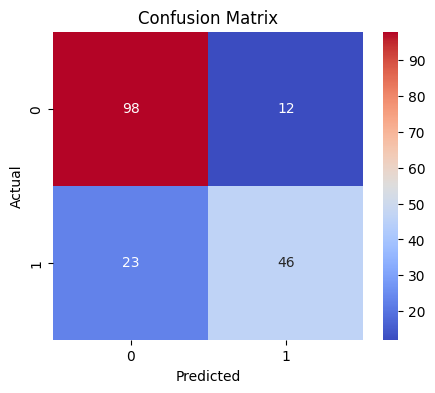

In [16]:
# 🔹 Confusion Matrix Plot
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

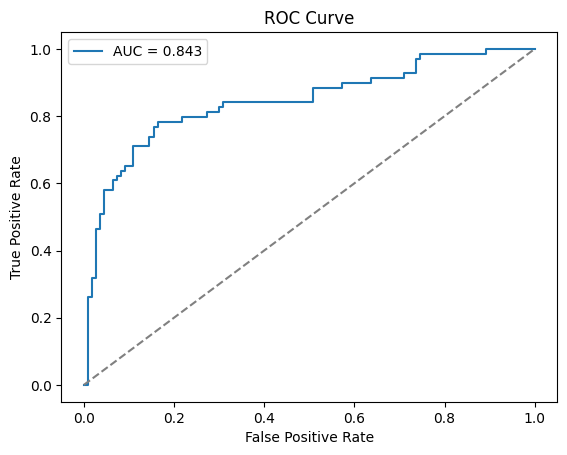

In [17]:
# 🔹 ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

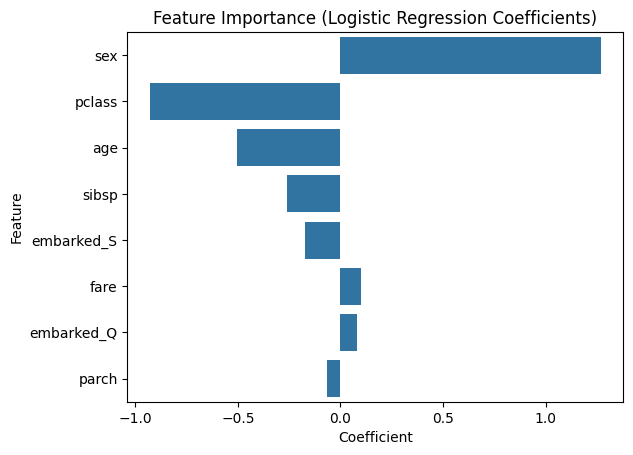

In [18]:
# 🔹 Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

sns.barplot(x='Coefficient', y='Feature', data=importance)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()

# AUC (Area Under Curve) = 0.843

This means your model has 84.3% probability of correctly distinguishing between survivors and non-survivors.

AUC ranges from:

0.5 → random guessing

1.0 → perfect model

So 0.843 = very good performance


# **Conclusions**



From the  chart:

sex → largest positive coefficient

This means being female significantly increases the chance of survival.

Matches Titanic’s real story (“women and children first”).

pclass → large negative coefficient

Lower passenger class (3rd class) reduced survival chances.

Higher classes (1st, 2nd) had better chances.

age → slightly negative

Older people had lower survival rates.

sibsp (siblings/spouses aboard) → slightly negative

Having many family members slightly reduced survival odds (possibly harder to escape together).

fare → small positive

Higher fare (richer passengers) meant better survival chance.

embarked_S, embarked_Q, parch → minimal effect

The port of embarkation and number of parents/children aboard had smaller influence.